# **Лекция 9. Немарковские модели СМО, оптимизационные решения**

 - Полумарковские, немарковские модели массового обслуживания.
 - Оптимизация решений на основе моделей массового обслуживания.

## **$\S 1.$ Полумарковские, немарковские модели массового обслуживания**

До настоящего времени мы в основном рассматривали только системы класса $M|M|\ldots$, предполагая, что входящий поток, поток обслуживания являются простейшими. Однако иногда приходится иметь дело с системами, для которых либо входящий поток, либо поток обслуживания являются немарковскими. 

Основная трудность здесь состоит в том, что количество заявок в системе в произвольный момент времени перестает быть марковским процессом, т.к. либо поток заявок, либо время обслуживания теперь обладает последействием.
В тоже время такой случайный процесс можно свести к марковскому процессу, поэтому его называют **полумарковским**.

Для решения этой задачи в основном используют два приема: метод вложенных цепей Маркова, метод дополнительной переменной.

### Метод вложенных цепей Маркова

Данный метод базируется на следующих идеях:
- СМО рассматривается не в произвольный момент времени $t$, а в некоторые специальным образом подобранные моменты времени $t_1, t_2,\ldots$.
- Эти моменты времени $t_k$ подбираются так, чтобы процесс $n(t_k)$ - число заявок в системе в момент времени $t_k$ был марковским процессом - цепью Маркова с дискретным временем.

Таким образом, отказавшись рассматривать систему в произвольный момент времени, мы можем опять вернуться к марковским процессам.

Рассмотрим систему $M|G|1|\infty$, пусть на вход поступает простейший поток заявок интенсивностью $\lambda$. Время обслуживания имеет произвольный закон распределения $F(t)$. Если мы будем рассматривать случайную величину $\nu(t)$ - число заявок в системе в момент времени $t$, то для нее проявляется зависимость распределения оставшегося времени дообслуживания от интервала времени, прошедшего с начала обслуживания. Поэтому нужно выбрать такие моменты, в которые этот факт не оказывал бы влияния на будущее.

В качестве $t_k$ выберем моменты окончания обслуживания $k$-й заявки. Пусть $\nu_k$ - число заявок в системе, которое осталось после ухода $k$-й по счету заявки, обозначим $\Delta_k$ - число заявок, которые пришли в систему за время обслуживания $k$-й заявки.
Имеем:
$$\nu_k=\begin{cases} \nu_{k-1}+\Delta_k-1, \nu_{k-1}>0\\
                                     \Delta_k, \nu_{k-1}=0
\end{cases}$$

Легко понять, что поскольку мы отказались рассматривать $\nu(t)$ в произвольный момент времени, то для моментов времени $t_k$ дообслуживания не возникает (заявка уходит из системы уже обслуженной), значит случайная величина $\nu_k$ образует цепь Маркова с дискретным временем.

Пусть $P(\Delta_k=n)$ - вероятность того, что за время обслуживания $k$-й заявки успело прийти $n$ новых заявок. Если время обслуживания $k$-й заявки составило $\tau=t_{k}-t_{k-1}$, то поскольку входящий поток простейший, случайная величина $\Delta_k$ подчиняется закону Пуассона, значит:
$$P(\Delta_k=n)=\frac{(\lambda\tau)^n}{n!}e^{-\lambda\tau}$$

Вероятность того, что $k$-я заявка будет обслуживаться не более $\tau$ определится как $P(t<\tau)=F(\tau)$ при известном произвольном законе распределения времени обслуживания. Совместное распределение, что обслуживание займет не более $\tau$ единиц времени и за это время поступит $n$ новых заявок выразится (получается путем усреднения по $\tau$):
$$f_n=\int_{0}^\infty\frac{(\lambda\tau)^n}{n!}e^{-\lambda\tau}dF(\tau)$$

Найдем теперь переходные вероятности. Обозначим $p_{ij}(\nu_k=j| \nu_{k-1}=i)$ - вероятность того, что в момент времени $t_k$ в системе будет находиться $\nu_k=j$ заявок, при условии, что в момент времени $t_{k-1}$ в системе находилось $\nu_{k-1}=i$ заявок.

Если $j<i-1$, то $p_{ij}=0$ (из системы уходит по одной заявке).

Если $i=0$, то $$p_{0j}=f_j=\int_{0}^\infty\frac{(\lambda\tau)^j}{j!}e^{-\lambda\tau}dF(\tau)$$
Если $j\geq i-1$, то $$p_{ij}=f_{j-i+1}=\int_{0}^\infty\frac{(\lambda\tau)^{j-i+1}}{(j-i+1)!}e^{-\lambda\tau}dF(\tau)$$

Окончательно, матрица переходных вероятностей имеет следующий вид:
$$\begin{equation}
P = \begin{pmatrix} f_0 & f_1 & f_2 & f_3 \ldots\\ f_0 & f_1 & f_2 & f_3 \ldots \\0 & f_0 & f_1 & f_3 \ldots \\ 0 & 0 & f_0 & f_1 & \ldots \\ 0 & 0 & 0 & f_0 & \ldots\\ \ldots & \ldots & \ldots & \ldots & \ldots\end{pmatrix} 
\end{equation}$$

Найдем финальные вероятности системы. Нужно отметить, что для их существования должны выполняться необходимые условия - интенсивность входящего потока должна быть меньше интенсивности потока обслуживания: $\frac{\lambda}{\mu}=\lambda\cdot M[\tau]<1$, где $M[\tau]=\frac{1}{\mu}=\int_0^\infty \tau dF(\tau)$.

Обозначим $\pi_n=\lim_{k\rightarrow \infty}P(\nu_k=n), n=0, 1, 2, \ldots$ - вероятность того, что в момент времени $t_k, k\rightarrow\infty$ в системе будет $n$ заявок.

В лекции 3 для нахождения стационарных вероятностей цепи Маркова с дискретным временем мы использовали условие:
$\pi\cdot (P-E)=0$, где $\pi = (\pi_0 \pi_1 \pi_2 \pi_3 \ldots)$- вектор-строка, а также условие нормировки $\sum_{n=0}^\infty\pi_n=1$. Тогда получаем:
$$(\pi_0 \pi_1 \pi_2 \pi_3 \ldots)\cdot \begin{pmatrix} 1 & f_1 & f_2 & f_3 \ldots\\ 1 & f_1-1 & f_2 & f_3 \ldots \\1 & f_0 & f_1-1 & f_3 \ldots \\ 1 & 0 & f_0 & f_1-1 & \ldots \\ 1 & 0 & 0 & f_0 & \ldots\\ \ldots & \ldots & \ldots & \ldots & \ldots\end{pmatrix}=(1 0 0 0 \ldots)$$

Это приводит к системе уравнений:
\\begin{cases} \sum_{n=0}^\infty\pi_n=1\\
               \pi_n = \pi_0f_n+\sum_{j=0}^n \pi_{n-j+1}\cdot f_{j}, n=1, 2, 3, \ldots\tag{1.1}
\end{cases}

Введем в рассмотрение производящие функции 
$$f(z)=\sum_{n=0}^\infty f_nz^n, \pi(z)=\sum_{n=0}^\infty \pi_nz^n$$

Умножив каждое $\pi_n$ из системы (1.1) на $z^n$ и сложив их все, получим:
$$\pi(z) = \sum_{n=0}^\infty\pi_n z^n = \pi_0\cdot f(z)+\sum_{n=0}^\infty z^n\cdot \sum_{j=0}^n\pi_{n-j+1}\cdot f_j \tag{1.2}$$

Выполним преобразования
$$\sum_{n=0}^\infty z^n\cdot \sum_{j=0}^n\pi_{n-j+1}\cdot f_j = \sum_{j=0}^\infty f_j\sum_{n=j}^\infty\pi_{n-j+1}\cdot z^n=\sum_{j=0}^\infty f_j\cdot z^j\cdot \sum_{n=j}^\infty\pi_{n-j+1}\cdot z^{n-j}=\sum_{j=0}^\infty f_jz^j\left(\sum_{k=0}^\infty\pi_{k+1}z^k\right)$$

В последнем выражении принято $k=n-j$, далее получаем:
$$\frac{\pi(z)}{z}=\sum_{n=0}^\infty \pi_n\cdot z^{n-1}=\frac{\pi_0}{z}+\sum_{k=0}^\infty \pi_{k+1}z^k$$
$$\sum_{k=0}^\infty\pi_{k+1}z^k=\frac{\pi(z)-\pi_0}{z}$$
$$\sum_{j=0}^\infty f_jz^j\left(\sum_{k=0}^\infty\pi_{k+1}z^k\right)=f(z)\cdot\frac{\pi(z)-\pi_0}{z}$$

Тогда из уравнения (1.2) получаем:
$$\pi(z)=\pi_0\cdot f(z)+f(z)\cdot\frac{\pi(z)-\pi_0}{z}$$
$$\pi(z)-\frac{f(z)\pi(z)}{z}=\pi_0f(z)-\frac{f(z)\pi_0}{z}$$
$$\pi(z)\left(1-\frac{f(z)}{z}\right)=\pi_0f(z)\left(1-\frac{1}{z}\right)$$
$$\pi(z)=\frac{\pi_0 f(z)(z-1)}{z-f(z)}\tag{1.3}$$

Выразим теперь $\pi_0$:
$$\lim_{z\rightarrow 1}\pi(z) = \sum_{n=0}^\infty\pi_n=1=\pi_0\lim_{z\rightarrow 1}\frac{f(z)(z-1)}{z-f(z)}$$

Для нахождения предела воспользуемся правилом Лопиталя, а также учтем условие нормировки $f(1)=1$:
$$1=\pi_0\lim_{z\rightarrow 1}\frac{f(z)(z-1)}{z-f(z)}=\pi_0\lim_{z\rightarrow 1}\frac{f'(z)z-f'(z)+f(z)}{1-f'(z)}=\pi_0\frac{1}{1-f'(1)}$$
Отсюда получаем $\pi_0=1-f'(1)$.

Таким образом, формулу (1.3) можно переписать следующим образом:
$$\pi(z) = \frac{(1-f'(1))\cdot f(z)\cdot(z-1)}{z-f(z)}\tag{1.4}$$

Формула (1.4) позволяет выразить среднее число заявок, находящихся в системе:
$$L_{\text{сист}}=\pi'(z)|_{z=1}=\left(\sum_{n=0}^\infty n\cdot z^{n-1}\cdot \pi_n\right)|_{z=1}$$
[Wolfram](https://www.wolframalpha.com/input?i=diff%28f%28z%29*%28z-1%29%2F%28z-f%28z%29%29%2Cz%29)
$$L_{\text{сист}}=\pi'(z)|_{z=1}=(1-f'(1))\cdot\lim_{z\rightarrow 1}\left(\frac{(z-1)zf'(z)-f^2(z)+f(z)}{(z-f(z))^2}\right)$$

Поскольку $f(1)=1$, при взятии предела возникает неопределенность, поэтому воспользуемся правилом Лопиталя:
$$L_{\text{сист}}=(1-f'(1))\cdot \lim_{z\rightarrow 1}\frac{f''(z)(z^2-z)+2zf'(z)-f'(z)-2f(z)f'(z)+f'(z)}{2(z-f(z))(1-f'(z))}$$
$$L_{\text{сист}}=(1-f'(1))\cdot \lim_{z\rightarrow 1}\frac{f''(z)(z^2-z)+2zf'(z)-2f(z)f'(z)}{2(z-f(z))(1-f'(1))}$$
$$L_{\text{сист}}=\lim_{z\rightarrow 1}\frac{f''(z)(z^2-z)+2zf'(z)-2f(z)f'(z)}{2(z-f(z))}$$
$$L_{\text{сист}}=\lim_{z\rightarrow 1}\left(\frac{f''(z)(z^2-z)}{2(z-f(z))}+\frac{2f'(z)(z-f(z))}{2(z-f(z))}\right)$$
$$L_{\text{сист}}=\lim_{z\rightarrow 1}\left(\frac{f''(z)(z^2-z)}{2(z-f(z))}+f'(z)\right)$$
$$L_{\text{сист}}=\lim_{z\rightarrow 1}\left(\frac{f''(z)(z^2-z)}{2(z-f(z))}\right)+f'(1)$$

Для последнего выражения опять используем правило Лопиталя:
$$L_{\text{сист}}=f'(1)+\lim_{z\rightarrow 1}\frac{f'''(z)(z^2-z)+2zf''(z)-f''(z)}{2(1-f'(z))}$$
$$L_{\text{сист}}=f'(1)+\frac{f''(1)}{2(1-f'(1))} \tag{1.5}$$

Остается найти явное выражение для $f(z)$.

$$f(z)=\sum_{n=0}^\infty f_nz^n=\sum_{n=0}^\infty z^n \int_{0}^\infty\frac{(\lambda\tau)^n}{n!}e^{-\lambda\tau}dF(\tau)=\int_{0}^\infty\left(\sum_{n=0}^\infty\frac{(\lambda\tau z)^n}{n!}\right)\cdot e^{-\lambda\tau}dF(\tau)$$

$$f(z)=\int_0^\infty e^{\lambda\tau z}e^{-\lambda \tau}dF(\tau)=\int_0^\infty e^{-\lambda(1-z)\tau}dF(\tau) \tag{1.6}$$

$$\frac{f(z)}{dz} = \lambda\int_{0}^\infty \tau\cdot e^{-\lambda(1-z)\tau}dF(\tau)$$

$$f'(1)=\lambda\int_{0}^\infty\tau dF(\tau) = \lambda M[\tau]$$

$$\frac{d^2f(z)}{dz^2}=\lambda^2\int_{0}^\infty \tau^2\cdot e^{-\lambda(1-z)\tau} dF(\tau)$$

$$f''(1) = \lambda^2\int_{0}^\infty \tau^2 dF(\tau)$$

Интеграл в последнем выражении - это начальный момент второго порядка случайной величины $\tau$, он имеет выражение через дисперсию:
$$D[\tau]=\int_0^\infty(\tau-M[\tau])^2dF(\tau)=\int_0^\infty\tau^2dF(\tau)-2M[\tau]\cdot\int_0^\infty \tau dF(\tau)+M^2[\tau]$$
$$D[\tau]=\int_0^\infty\tau^2dF(\tau)-2M^2[\tau]+M^2[\tau]$$
$$f''(1) = \lambda^2\int_0^\infty\tau^2dF(\tau) = \lambda^2(D[\tau]+M^2[\tau])$$

Подставляя полученные выражения в формулу (1.5), получаем:
$$L_{\text{сист}}=\lambda M[\tau]+\frac{\lambda^2(D[\tau]+M^2[\tau])}{2(1-\lambda M[\tau])} \tag{1.7}$$

Выражение (1.7) позволяет находить среднее число заявок, находящихся в системе для СМО вида $M/G/1/\infty$, и носит название **формулы Поллачека-Хинчина для среднего значения**.

Подчеркнем, что распределение числа требований зависит только от первых двух моментов распределения случайной величины $\tau$. Используя формулу Литтла, можно также найти и остальные параметры системы:
$$T_{\text{сист}}=\frac{L_{\text{сист}}}{\lambda}=M[\tau]+\frac{\lambda(D[\tau]+M^2[\tau])}{2(1-\lambda M[\tau])} \tag{1.8}$$
$$W_{\text{оч}}=T_{\text{сист}}-M[\tau]=\frac{\lambda(D[\tau]+M^2[\tau])}{2(1-\lambda M[\tau])} \tag{1.9}$$
$$L_{\text{оч}} = W_{\text{оч}}\cdot \lambda = \frac{\lambda^2(D[\tau]+M^2[\tau])}{2(1-\lambda M[\tau])} \tag{1.10}$$

Вспоминая, что преобразование Лапласа-Стилтьеса:
$$B(s)=\int_0^\infty e^{-s\tau}dF(\tau)$$
и сопоставляя это с формулой (1.6), получаем:
$$f(z)=B(\lambda(1-z))$$

Тогда используя формулу (1.4), получаем:

$$\pi(z) = \frac{(1-\lambda M[\tau])\cdot B(\lambda(1-z))\cdot(z-1)}{z-B(\lambda(1-z))}\tag{1.11}$$

Формула (1.11) называется **формулой Поллачика-Хинчина для преобразования**, которая позволяет вычислять значения стационарных  вероятностей нахождения в СМО $n=0,1,2,3,\ldots$ заявок в моменты окончания обслуживания при $t_k, k\rightarrow \infty$. (Данное уравнение было получено в 1932 году А.Я. Хинчиным.)

Рассмотрим ряд примеров на использование формул Поллачека-Хинчина (1.7)-(1.11).

**Пример 1.**

Рассмотрим в качестве примера экспоненциальное распределение закона обслуживания:
$F(t) = 1-e^{-\mu t}$
$$M[\tau]=\frac{1}{\mu}, D[\tau] = \frac{1}{\mu^2}$$
Обозначим $y=\frac{\lambda}{\mu}$, тогда по формуле (1.7) имеем:
$$L_{\text{сист}}=y+\frac{2y^2}{2(1-y)}=\frac{y}{1-y}$$

Это совпадает с известной нам формулой (см. формулу (3.3) лекции 4). Аналогично получаем остальные показатели.

Теперь воспользуемся формулой (1.11), чтобы получить $\pi_n = \lim_{k\rightarrow \infty}P(\nu_k=n), n=0, 1, 2, \ldots$ - вероятность того, что в момент времени $t_k, k\rightarrow\infty$ в системе будет $n$ заявок:
$$B(s) = B(\lambda-\lambda z) = \int_0^\infty e^{-st}dF(t) = \int_0^\infty \mu e^{-\mu t}e^{-st}dt$$


$$B(s) = \mu\int_0^\infty e^{-(\mu+s)t}dt = -\frac{\mu}{\mu+s}\int_0^\infty d e^{-(\mu+s)t} =\frac{\mu}{\mu+s}=\frac{\mu}{\mu+\lambda-\lambda z}$$

$$\pi(z) = \frac{\left(1-\frac{\lambda}{\mu}\right)(z-1)}{z-\frac{\mu}{\mu+\lambda-\lambda z}}\cdot \frac{\mu}{\mu+\lambda-\lambda z}=\frac{(z-1)(\mu-\lambda)}{\mu z+\lambda z -\lambda z^2 - \mu}= \frac{(1-z)(\mu-\lambda)}{\lambda z^2-(\mu+\lambda)z +\mu}$$

Выражение $\lambda z^2-(\mu+\lambda)z +\mu$ разложим на множители по $z$:
$$z_{1,2} = \frac{\mu+\lambda\pm\sqrt{(\mu+\lambda)^2-4\mu\lambda}}{2\lambda} = \frac{\mu+\lambda\pm|\mu-\lambda|}{2\lambda}$$

Поскольку $\frac{\lambda}{\mu}<1\Rightarrow \mu-\lambda >0$, то
$$z_1 = \frac{\mu}{\lambda}, z_2 = 1$$
$$\lambda z^2-(\mu+\lambda)z +\mu = \lambda(z-1)(z-\frac{\mu}{\lambda})$$

$$\pi(z) = \frac{(1-z)(\mu-\lambda)}{\lambda(z-1)\left(z-\frac{\mu}{\lambda}\right)} = \frac{1-y}{1-yz}, y = \frac{\lambda}{\mu}$$

Последнее выражение разложим в ряд по переменной $z$:

[Wolfram](https://www.wolframalpha.com/input?i=series%28+%281-y%29%2F%281-y*z%29%2C+z%29)

$$\pi(z) = (1-y) +(1-y)yz+(1-y)y^2z^2+(1-y)y^3z^3+\ldots \tag{1.12}$$

Как видно, полученный результат $P_0 = (1-y), P_k = (1-y)y^k$ совпадает с вероятностями нахождения системы $M/M/1/\infty$ в состояниях $S_0, S_k$  из лекции 4. Однако, равенство (1.12) получено для момента ухода обслуженных заявок, в то время как результаты в лекции 4 справедливы для любого момента времени. 

Это совпадение не является случайным. Во вложенных цепях Маркова мы устраняли наличие последействия рассмотрением только определенных моментов времени - ухода обслуженных заявок.

Но легко понять, что последействие будет отсутствовать и когда мы будем рассматривать заявки за секунду до или после ухода обслуженной (в общем случае в любой фиксированный момент времени от события ухода обслуженных заявок). При отсутствии последействия все рассуждения остаются в силе для этих моментов времени. Таким образом, вложенные марковские цепи дают решение, справедливое для любых точек оси времени. 

**Пример 2.**

Рассмотрим теперь систему с детерминированным временем обслуживания $M/D/1/\infty$. В ней $M[\tau]=T$ - постоянная величина времени обслуживания, $D[\tau] = 0$, тогда получаем:
$$L_{\text{сист}} = \lambda T+\frac{\lambda^2 T^2}{2(1-\lambda T)} = \frac{2\lambda T-\lambda^2 T^2}{2(1-\lambda T)}$$

$$T_{\text{сист}} = \frac{2T-\lambda T^2}{2(1-\lambda T)}$$

$$W_{\text{оч}} = \frac{\lambda T^2}{2(1-\lambda T)}$$

$$L_{\text{оч}} = \frac{\lambda^2 T^2}{2(1-\lambda T)}$$

Зададимся числовыми значениями $\lambda = 3, T =0.3$, условие $\lambda\cdot T=3\cdot 0.3 <1$ - выполняется. 

Проведем расчет по полученным формулам, а также выполним моделирование и сравним результаты.

In [1]:
lambda <- 3
T <- 0.3
Lsys <- (2*lambda*T-lambda^2*T^2)/(2*(1-lambda*T))
Woch <- lambda*T^2/(2*(1-lambda*T))
Tsys<-(2*T-lambda*T^2)/(2*(1-lambda*T))
Loch<-lambda^2*T^2/(2*(1-lambda*T))
cat("Lsys = ", Lsys)
cat("\nTsys = ", Tsys)
cat("\nLoch = ", Loch)
cat("\nWoch = ", Woch)

Lsys =  4.95
Tsys =  1.65
Loch =  4.05
Woch =  1.35

In [2]:
#Моделирование детерминированного обслуживания

library(simmer)
library(simmer.plot)

my.trajectory2 <- trajectory() %>%
  seize("server", amount=1) %>%
  timeout(T) %>%
  release("server", amount=1)

Tmodel<-200000
md_1_inf <- simmer() %>%
  add_resource("server", capacity=1, queue_size=Inf) %>%
  add_generator("arrival", my.trajectory2, function() rexp(1, lambda)) %>%
  run(until=Tmodel)

Загрузка требуемого пакета: ggplot2


Присоединяю пакет: ‘simmer.plot’


Следующие объекты скрыты от ‘package:simmer’:

    get_mon_arrivals, get_mon_attributes, get_mon_resources




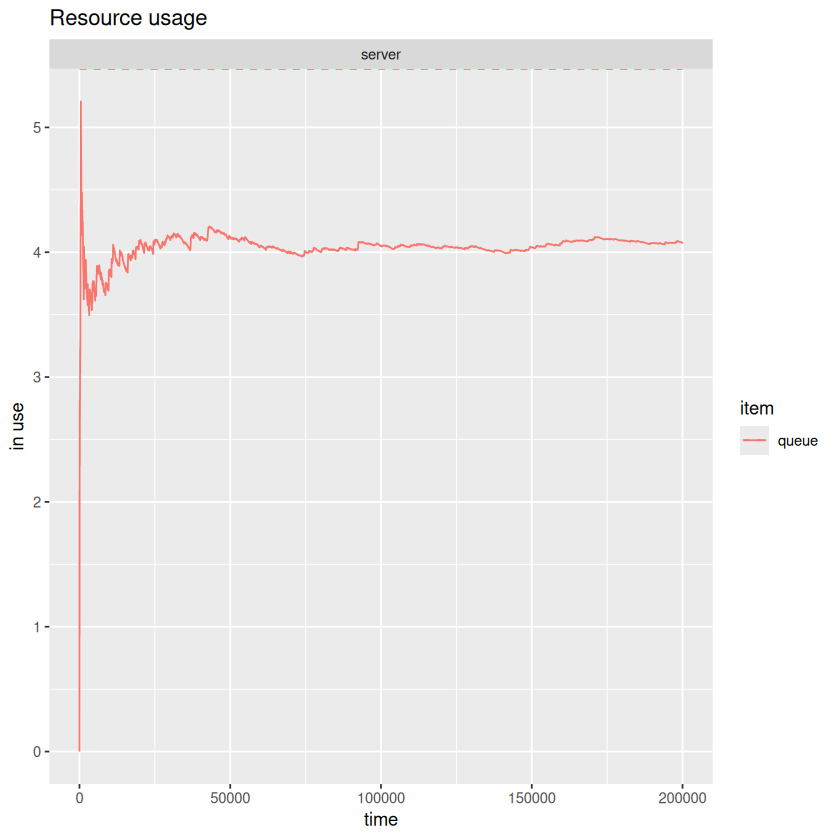

In [6]:
#Находим среднюю длину очереди
L_och <- plot(get_mon_resources(md_1_inf), "usage", "server", items="queue")
L_och

In [8]:
mean(L_och@data$mean)

[1] 4.04047

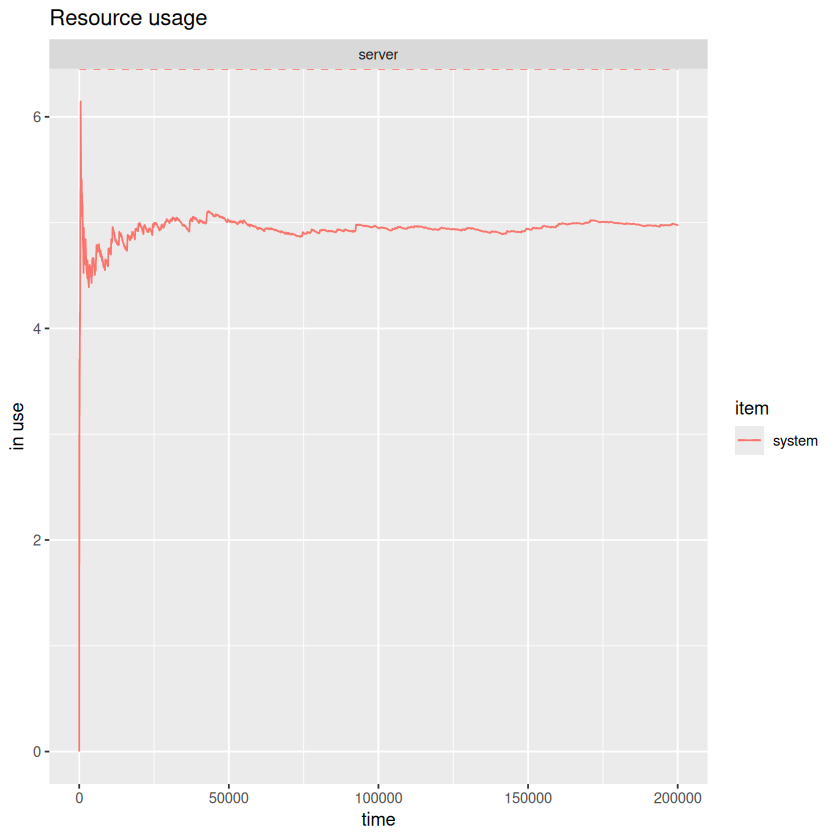

In [9]:
#Находим среднее число заявок в системе
Lsys <- plot(get_mon_resources(md_1_inf), "usage", "server", items="system")
Lsys

In [10]:
mean(Lsys@data$mean)

[1] 4.940363

In [11]:
res_arrivals <- get_mon_arrivals(md_1_inf)
cat("Tsys =", mean(res_arrivals$end_time - res_arrivals$start_time))
cat("\nWoch =", mean(res_arrivals$end_time - res_arrivals$start_time-res_arrivals$activity_time))

Tsys = 1.658432
Woch = 1.358432

### Системы класса $GI/GI/1/\infty$ - немарковские процессы

В общем случае для такого рода систем не существует точных формул.

Пусть входящий поток и поток обслуживания являются стационарными, ординарными с ограниченным последействием и произвольным законом распределения интервалов времени между моментами поступления заявок в систему (для входящего потока) и между моментами времени ухода заявки обслуженной (для потока обслуживания). Такие потоки называются **рекуррентными** и обозначаются $GI$.

Итак, будем рассматривать систему $GI/GI/1/\infty$, в которую поступает рекуррентный поток заявок с интенсивностью $\lambda$. Интервалы времени между заявками – независимые случайные величины с функцией распределения $А(t)$, средним значением $M[\tau] =\bar{\tau} = \frac{1}{\lambda}$, и коэффициентом вариации $v_\tau = \frac{\sigma_\lambda}{\bar{\tau}}=\lambda\cdot \sigma_{\tau}$ и дисперсией $D[\tau] = \sigma^2_\tau$. Время обслуживания заявки в системе $x$ также независимая случайная величина со средним значением $M[x] = \bar{x}=\frac{1}{\mu}$, которая имеет произвольную функцию распределения $В(t)$ и коэффициент вариации $v_{\mu}=\frac{\sigma_x}{\bar{x}}=\mu\cdot\sigma_x$, дисперсию $D[x]=\sigma^2_x$. Поскольку число каналов в системе $k = 1$, то ее коэффициент загрузки $y=\frac{\lambda}{\mu}$.

Для такой системы известны следующие результаты:

- **Неравенство Кингмана - Келлерстрема** [1, 2, 3, 4] - верхнее ограничение на длину очереди:
$$L_{\text{оч}}\leq \frac{v_\lambda^2+y^2v_\mu^2}{2(1-y)} \tag{13}$$
- в [1, 2] приводится также нижнее ограничение:
$$L_{\text{оч}}\geq \frac{y^2v_\mu^2}{2(1-y)}-\frac{y}{2} \tag{14}$$
 - в [1, 2, 3]  обосновывается, что на практике удобнее пользоваться **формулой Файнберга**:
 $$L_{\text{оч}}\approx \frac{y^2(v_\lambda^2+v_\mu^2)}{2(1-y)} \tag{15}$$
 Используя формулу (15) и формулу Литтла, можно выразить остальные характеристики системы:
 $$W_{\text{оч}} \approx \frac{y^2(v_\lambda^2+v_\mu^2)}{2\lambda(1-y)} \tag{16}$$
 $$L_{\text{сист}}\approx \frac{y^2(v_\lambda^2+v_\mu^2)}{2(1-y)}+y \tag{17}$$
 $$T_{\text{сист}}\approx \frac{y^2(v_\lambda^2+v_\mu^2)}{2\lambda(1-y)}+\frac{1}{\mu} \tag{18}$$

- В [5] используется еще одна аппроксимация, получившая название **аппроксимация Маршалла**:

$$W_{\text{оч}}\approx \frac{y M[x]}{2(1-y)}\cdot \left(\frac{D[\tau]+D[x]}{M^2[x]}\right)\cdot\left(\frac{M^2[x]+D[x]}{M^2[\tau]+D[x]}\right) \tag{19}$$

[1] Задорожный В. Н., Галич  Ю. Г., ОЦЕНКА ТОЧНОСТИ ПРИБЛИЖЕННЫХ ФОРМУЛ ДЛЯ СРЕДНЕЙ ДЛИНЫ ОЧЕРЕДИ /  СИСТЕМЫ УПРАВЛЕНИЯ, ИНФОРМАЦИОННЫЕ ТЕХНОЛОГИИ И МАТЕМАТИЧЕСКОЕ МОДЕЛИРОВАНИЕ. Материалы II Всероссийской научно-практической конференции с международным участием. В 2-х томах . Том I.

[2] Платонов Г. А., Файнберг М. А., Штильман М. С. Поезда, пассажиры и... математика. М. :
Транспорт, – 1977. 239 с.

[3] Вентцель Е. С., Задачи и упражнения по теории вероятностей: Учеб. пособие для студ. втузов / Е. С. Вентцель, Л. А. Овчаров. — 5-е изд., испр. — М.: Издательский центр «Академия», 2003. — 448 с.

[4] Клейнрок Л. Вычислительные системы с очередями / пер. с англ. под ред. Б. С. Цыбакова.
М. : Мир, 1979. – 600 с.

[5] https://studfile.net/preview/11297923/page:7/

**Пример 3.**

Проведем оценку точности этих формул на примере.Например, рассмотрим $E_2/M/1/\infty$ при $\lambda' = 2/5, \mu = 1/3$.
Для потока Эрланга $k$-го порядка справедливо:
$$M[t] = \frac{k}{\lambda'}, D[t] = \frac{k}{\lambda'^2}, v^2 = \frac{D[t]}{M^2[t]} = \frac{1}{k}$$
В нашем случае получаем:
$$M[\tau] = \frac{2}{2/5} = 5, D[\tau] = \frac{2}{4/25} = \frac{25}{2}, v^2_\lambda = \frac{1}{2}, \lambda = \frac{1}{M[\tau]} = 1/5$$

$$M[x] = 3, D[x] = 9, v^2_\mu =1$$

$$y = \frac{\lambda}{\mu} =\frac{3}{5}$$

Расчеты по формуле Файнберга:
$$W_{\text{оч}} \approx \frac{y^2(v_\lambda^2+v_\mu^2)}{2\lambda(1-y)} \approx 3.375$$

$$T_{\text{сист}} = W_{\text{оч}} + \frac{1}{\mu} \approx 6.378$$

$$L_{\text{оч}}\approx \frac{y^2(v_\lambda^2+v_\mu^2)}{2(1-y)} \approx 0.675$$

$$L_{\text{сист}}\approx \frac{y^2(v_\lambda^2+v_\mu^2)}{2(1-y)}+y \approx 1.275$$

In [7]:
y <- 0.6
lambda <-0.2
mu<-0.333
vmu2 <- 1
vlambda2 <- 1/2
Woch<-y^2*(vmu2+vlambda2)/(2*lambda*(1-y));cat('Woch = ',Woch)
Tsys<-Woch+1/mu; cat('\nTsys = ',Tsys)
Loch<-y^2*(vmu2+vlambda2)/(2*(1-y));cat('\nLoch = ',Loch)
Lsys<-Loch+y;cat('\nLsys = ',Lsys)

Woch =  3.375
Tsys =  6.378003
Loch =  0.675
Lsys =  1.275

Расчеты в соответствии с неравенством Кингмана - Келлерстрема:
$$\frac{y^2v_\mu^2}{2(1-y)}-\frac{y}{2}\leq L_{\text{оч}}\leq \frac{v_\lambda^2+y^2v_\mu^2}{2(1-y)}$$
$$0.15\leq L_{\text{оч}}\leq 1.075$$

In [26]:
Lochniz<-y^2*vmu2/(2*(1-y))-y/2;cat('Lochniz = ',Lochniz)
Lochverch<-(vlambda2+y^2*vmu2)/(2*(1-y));cat('\nLochverch = ',Lochverch)

Lochniz =  0.15
Lochverch =  1.075

Расчеты в соответствии с аппроксимацией Маршалла:
$$W_{\text{оч}}\approx \frac{y M[x]}{2(1-y)}\cdot \left(\frac{D[\tau]+D[x]}{M^2[x]}\right)\cdot\left(\frac{M^2[x]+D[x]}{M^2[\tau]+D[x]}\right) \approx 2.85$$

In [8]:
Mx<-3; Mtau<-5; Dlambda<-12.5; Dmu<-9
Woch<-y*Mx/(2*(1-y))*((Dlambda+Dmu)/(Mx^2))*((Mx^2+Dmu)/(Mtau^2+Dmu)); cat('Woch = ',Woch)

Woch =  2.845588

Теперь проведем моделирование.

In [13]:
# https://search.r-project.org/CRAN/refmans/distributions3/html/Erlang.html

install.packages("distributions3")

In [2]:
# Генерим 10 случайных чисел по распределению Эрланга E_5 при lambda' = 2
library(distributions3)
X <- Erlang(5, 2)
random(X,10)


Присоединяю пакет: ‘distributions3’


Следующий объект скрыт от ‘package:stats’:

    Gamma


Следующий объект скрыт от ‘package:grDevices’:

    pdf




[1] 2.795815 2.011322 2.670291 1.969014 5.104636 1.049287 3.661100 1.525318
 [9] 3.234449 3.345249

In [1]:
#Моделирование 
lambda_shtrich <- 2/5; mu <- 1/3

library(simmer)
library(simmer.plot)
library(distributions3)


my.trajectory2 <- trajectory() %>%
  seize("server", amount=1) %>%
  timeout(function() rexp(1,mu)) %>%
  release("server", amount=1)

Tmodel<-800000
E2M1inf <- simmer() %>%
  add_resource("server", capacity=1, queue_size=Inf) %>%
  add_generator("arrival", my.trajectory2, function() random(Erlang(2, lambda_shtrich),1)) %>%
  run(until=Tmodel)

Загрузка требуемого пакета: ggplot2


Присоединяю пакет: ‘simmer.plot’


Следующие объекты скрыты от ‘package:simmer’:

    get_mon_arrivals, get_mon_attributes, get_mon_resources



Присоединяю пакет: ‘distributions3’


Следующий объект скрыт от ‘package:stats’:

    Gamma


Следующий объект скрыт от ‘package:grDevices’:

    pdf




In [3]:
res_arrivals <- get_mon_arrivals(E2M1inf)
cat("Tsys =", mean(res_arrivals$end_time - res_arrivals$start_time))
cat("\nWoch =", mean(res_arrivals$end_time - res_arrivals$start_time-res_arrivals$activity_time))

Tsys = 5.955659
Woch = 2.957153

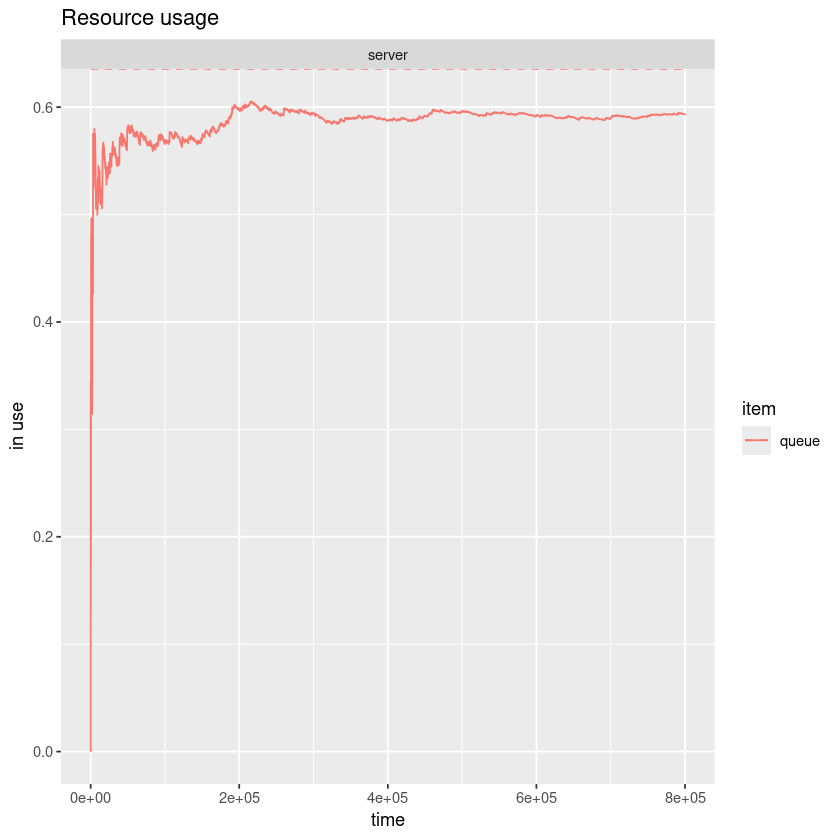

In [4]:
#Находим среднюю длину очереди
plot(get_mon_resources(E2M1inf), "usage", "server", items="queue")

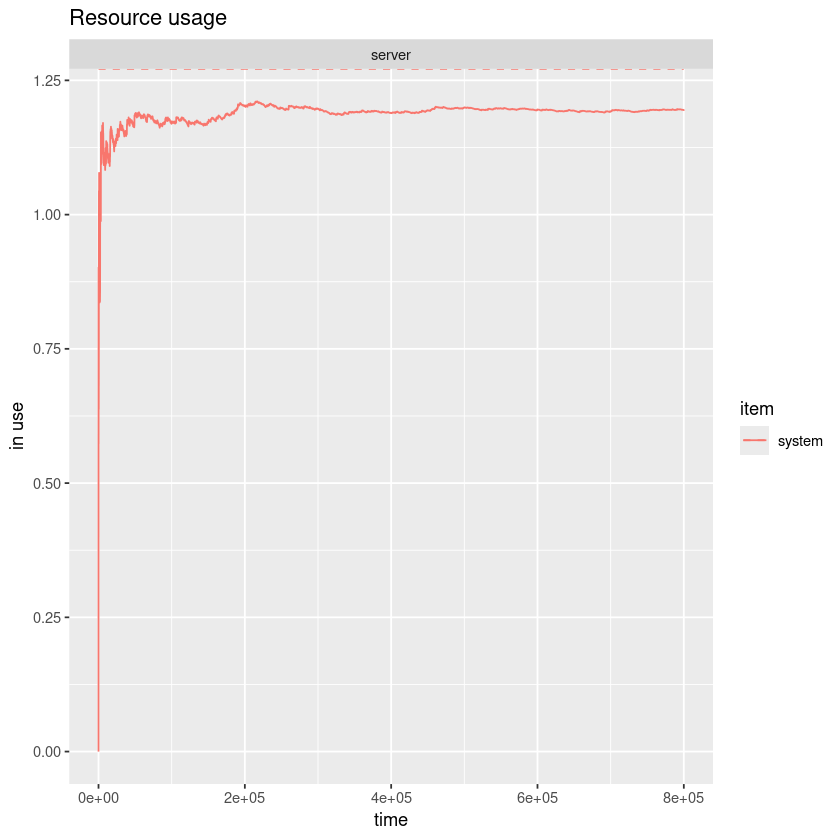

In [5]:
#Находим среднее число заявок в системе
plot(get_mon_resources(E2M1inf), "usage", "server", items="system")

## **$\S 2.$ Оптимизация решений на основе моделей массового обслуживания**

До сих пор мы в основном рассматривали показатели эффективности систем СМО. Однако использование СМО без учета и оптимизации экономических характеристик вряд ли возможно. 

Под экономическими характеристиками понимаются величины, выражающие прибыль от работы СМО, затраты на обслуживание заявок и т.д. Расчет таких характеристик зависит от постановки задачи. Приведем несколько
общих формул, применимых в большинстве задач:

- **Выручка от обслуживания заявок в СМО в течение времени $T$**:
$$V=\lambda'\cdot C\cdot T\tag{35}$$
где $\lambda'$ - пропускная способность СМО;
$C$ - выручка о обслуживания одной заявки.
 - **Затраты, связанные с обслуживанием заявок в СМО в течение времени $T$**:
 $$Z_{\text{обс}}=\lambda'\cdot C_{\text{обс}}\cdot T\tag{36}$$
 где $C_{\text{обс}}$ - затраты, связанные с обслуживанием одной заявки.
 - **Затраты, связанные с эксплуатацией СМО в течение времени T**:
 $$Z_{\text{эксп}}=\left(\bar{k}\cdot C_{\text{раб}}+(m-\bar{k})\cdot C_{\text{пр}}\right)\cdot T\tag{37}$$
 где $\bar{k}$ - среднее число занятых каналов;
 $C_{\text{раб}}$ - затраты, связанные с работой одного канала в течение единицы времени;
 $m$ - количество каналов в СМО;
 $C_{\text{пр}}$ - затраты, связанные с простоем одного канала в течение единицы времени.
 - **Убытки, связанные с отказами в обслуживании за время T**:
 $$Z_{\text{отк}}=\lambda\cdot C_{\text{отк}}\cdot P_{\text{отк}}\cdot T\tag{38}$$
 где $\lambda$ - интенсивность потока заявок;
 $C_{\text{отк}}$ - убытки, связанные с отказом в обслуживании одной заявки;
 $P_{\text{отк}}$ - вероятность отказа.
 - **Убытки за время T, связанные с пребыванием заявок в СМО (как в очереди, так и на обслуживании)**:
 $$Z_{\text{пр}}=L_{\text{сист}}\cdot C_{\text{пр}}\cdot T\tag{39}$$
 где $L_{\text{сист}}$ - среднее число заявок в СМО;
 $C_{\text{пр}}$ - убытки, связанные с пребыванием заявки в СМО в течение единицы времени.

Также мы в основном рассматривали системы $M/M/n/m, m=0,1,\ldots, \infty$, но на практике далеко не всегда входной и выходной потоки являются простейшими. Для расчетов экономических характеристик в этих случаях используют приближенные формулы, которые мы рассмотрели (например, формула Файнберга). Для этого часто используют коэффициенты вариации интервалов времени между заявками и времени обслуживания заявок. Физический смысл коэффициента вариации следующий: чем он больше, тем больше разброс возможных значений случайной величины, т.е. отклонение ее отдельных значений от среднего значения.

|Распредедение | Коэффициент вариации|
|--------------|---------------------|
|Экспоненциальное $M$| 1 |
|Эрланг $k$-го порядка $E_k$| $\frac{1}{\sqrt{k}}$ |
|Равномерное $G$ в интервале $[a,b]$| $\frac{b-a}{(a+b)\cdot \sqrt{3}}$|
|Детерминированное $D$| 0|

В дальнейшем будем обозначать коэффициент вариации интервалов времени между заявками как $v$, а коэффициент вариации времени обслуживания  - как $\epsilon$.

Рассмотрим ряд примеров.

**Пример 6.** Генеративый ИИ "Вася" используется для формирования ответов пользователям. Интервалы между моментами поступления запросов от пользователей составляют от 7 до 15 минут. Время выполнения запроса - случайная величина с нормальным законом распределения со средним значением 2 мин стандартным отклонением 0.1 мин. Затраты на один час работы "Васи" (потребление элекроэнергии всем программно-аппаратным комплексом) составляет 10 у.е., на один час простоя 3 у.е. За выполнение одного запроса пользователи платят 0.5 у.е., за ожидание ответа пользователям возвращают 0.01 у.е. на 1 минуту ожидания ответа.  Оценить среднюю прибыль от работы "Васи" за одну рабочую смену (8 часов).

**Решение**.  Интервалы времени между моментами поступления запросов представляют собой случайные величины, распределенные по равномерному закону. Время обработки запросов – гауссовская случайная величина. Система одноканальная.

Таким образом, имеем СМО класса $G/G/1$, поэтому возможен только приближенный расчет.

Средний интервал времени между запросами составляет $\frac{15-7}{2}=4$ мин., значит, $\lambda=\frac{1}{4}\approx 0.25$ запроса в минуту , обработка одного запроса занимает $2$ мин. т.е. $\mu=1/2=0.5$ запросов в минуту.

Нагрузка системы: $y=\frac{\lambda}{\mu}\approx 0.5$

Коэффициент вариации для для интервалов между моментами поступления запросов для равномерного закона: $v=\frac{b-a}{\sqrt{3}\cdot (a+b)}=\frac{15-7}{\sqrt{3}\cdot 22}\approx 0.21$

Коэффициент вариации для времени обработки запросов $\epsilon=0.1/2=0.05$.

Длину очереди можно оценить по формуле Файнберга: $L_{\text{оч}}=\frac{y^2\cdot(v^2+\epsilon^2)}{2(1-y)}=\frac{0.5^2\cdot(0.21^2+0.05^2)}{2\cdot(1-0.5)}\approx 0.012$ запросов.

Будем считать, что "Вася" обрабатывает все поступающие запросы, тогда $P_{\text{отк}}=0, \lambda'=\lambda=0.25$.

Средняя выручка от работы "Васи" за смену:

$$V=\lambda'\cdot C\cdot T=0.25\cdot 0.5\cdot 8\cdot 60\approx 60 \text{у.е.}$$

Среднее число занятых каналов $\bar{k}=y$

Затраты, связанные с эксплуатацией СМО в течение времени T:
 $$Z_{\text{эксп}}=\left(\bar{k}\cdot C_{\text{раб}}+(m-\bar{k})\cdot C_{\text{пр}}\right)\cdot T=(0.5\cdot 10+(1-0.5)\cdot 3)\cdot 8\approx 52$$
 
Среднее время пребывания заявки в системе: 
$$T_{\text{сист}}=W_{\text{оч}}+\frac{1}{\mu}=\frac{L_{\text{оч}}}{\lambda}+\frac{1}{\mu}=\frac{0.012}{0.25}+\frac{1}{0.5}\approx 2.048\text{минут}$$

Среднее число заявок в системе:

$$L_{\text{сист}}=\lambda\cdot T_{\text{сист}}=\bar{k}+L_{\text{оч}}=0.25\cdot 2.048= 0.5+0.012\approx 0.512$$
 
Убытки за время T, связанные с пребыванием заявок в СМО (как в очереди, так и на обслуживании):
 $$Z_{\text{пр}}=L_{\text{сист}}\cdot C_{\text{пр}}\cdot T\approx 0.512\cdot 0.01\cdot 8\cdot 60\approx 2.46 \text{у.е./смена}$$

Чистая прибыль от работы "Васи" составит:
$$\text{П}=60-52-2.46\approx 5.54 \text{у.е.}$$

**Пример 7. СМО с заявками с разным временем обслуживания.**
Программы, при разработке которых допущена ошибка, направляются для устранения дефекта к эксперту (система ИИ copilot). При разработке программы возможны ошибки трех видов (обозначим их как A, B и C). Программы, имеющие несколько ошибок (две или три) одновременно, отклоняются; поэтому каждая программа, поступающая к эксперту, имеет только одну ошибку. Программы, имеющие ошибку A, поступают к эксперту в среднем через каждые 20 мин, с ошибкой B – через каждые 10 мин, с ошибкой C – через каждые 25 мин. Потоки программ с ошибками каждого вида можно считать пуассоновскими. Устранение ошибки A занимает от 2 до 5 мин, устранение ошибки B – ровно 5 мин; время устранения ошибки C представляет собой гауссовскую случайную величину со средним значением 7 мин и стандартным отклонением 1.5 мин. Требуется найти характеристики работы эксперта.

В таких СМО обслуживаются заявки нескольких типов, различающихся по времени обслуживания. Пусть в СМО обслуживается R типов заявок. Обозначим долю заявок $i$-го типа в потоке заявок как $P_i$ , $i=1,\ldots,R$, $P_1 + P_2 +\ldots+P_R=1$.

Времена обслуживания заявок разных типов представляют собой случайные (или детерминированные) величины; для расчета характеристик СМО законы распределения этих величин должны быть известны. Среднее время обслуживания заявки $i$-го типа обозначим как $\bar{x}_i$ , $i=1,\ldots, R$. Для расчета характеристик таких СМО необходимо определить среднее время обслуживания и коэффициент вариации времени обслуживания всех заявок в СМО.

Среднее время обслуживания заявок находится по формуле:
$$\bar{x}=\sum_{i=1}^R P_i\cdot \bar{x}_i$$

Коэффициент вариации вычисляется следующим образом.

1. Находятся дисперсии времени обслуживания заявок каждого типа: $D_i$, $i=1,\ldots,R$. Для этого должны быть известны законы распределения времени обслуживания заявок.
2. Находятся вторые начальные моменты времени обслуживания заявок каждого типа:
$$\alpha_i = D_i + \bar{x}_i^2 , i=1,\ldots,R.$$
3. Находится второй начальный момент времени обслуживания всех заявок:
$$\alpha=\sum_{i=1}^R P_i\cdot \alpha_i$$
4. Находится дисперсия времени обслуживания всех заявок:
$$D=\alpha-\bar{x}^2$$
5. Находится коэффициент вариации времени обслуживания всех заявок:
$$\epsilon=\frac{\sqrt{D}}{\bar{x}}$$

Так как потоки программ с ошибками каждого вида можно считать пуассоновскими, поток всех программ также можно считать пуассоновским. Найдем интенсивности потоков программ с ошибками каждого вида: $\lambda_A =1/20=0.05$ программы/мин, $\lambda_B =1/10=0.1$ программы/мин, $\lambda_C =1/25=0.04$ программы/мин. Интенсивность потока всех программ представляет собой сумму интенсивностей отдельных потоков: $\lambda=\lambda_A+\lambda_B+\lambda_C=0.19$ программ/мин.

Найдем доли программ каждого вида в общем потоке: $$P_A =0.05/0.19=0,26; P_B =0.1/0.19=0.53; P_C =0.04/0.19=0.21$$

Найдем среднее время обработки программ всех видов. Средние времена обработки программ каждого вида следующие: 
$$\bar{x}_A =(2+5)/2=3,5\text{мин}, \bar{x}_B =5 \text{мин}, \bar{x}_C =7 \text{мин}$$ 

Среднее время обработки программ всех видов: 
$$\bar{x} =0.26·3.5+0.53·5+0.21·7=5.03 \text{мин}$$



**Продолжить самостоятельно**